COLAB E-ii — TensorFlow High-Level Built-In Layers

Cell 1 — Install & Imports

In [9]:
!pip install tensorflow scikit-learn matplotlib --quiet

import tensorflow as tf
from tensorflow.keras import layers, Model
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

tf.random.set_seed(42)
np.random.seed(42)

Cell 2 — Generate Synthetic Data

Same nonlinear regression function:
y=sin(x1​)+x22​+log(x32​+1)

In [10]:
N = 1000
x1 = np.random.uniform(-3, 3, N)
x2 = np.random.uniform(-2, 2, N)
x3 = np.random.uniform(-2, 2, N)

X = np.stack([x1, x2, x3], axis=1).astype(np.float32)
y = (np.sin(x1) + x2**2 + np.log(x3**2 + 1)).astype(np.float32).reshape(-1,1)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000, 3)
y shape: (1000, 1)


Cell 3 — Define the Neural Network (Built-In Layers)

We use tf.keras built-in layers for a 3-layer deep network:

In [11]:
class DeepRegModel(Model):
    def __init__(self):
        super(DeepRegModel, self).__init__()
        self.d1 = layers.Dense(64, activation='relu')
        self.d2 = layers.Dense(32, activation='tanh')
        self.d3 = layers.Dense(16, activation='relu')
        self.out = layers.Dense(1)  # linear activation for regression

    def call(self, x):
        x = self.d1(x)
        x = self.d2(x)
        x = self.d3(x)
        return self.out(x)

model = DeepRegModel()

Cell 4 — Compile the Model

We set optimizer and loss for regression:

In [12]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mse']
)

model.summary()

Model: "deep_reg_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Cell 5 — Train the Model

Train with built-in .fit():

In [13]:
history = model.fit(X, y, epochs=500, batch_size=32, verbose=2)

Epoch 1/500
32/32 - 1s - 43ms/step - loss: 3.4832 - mse: 3.4832
Epoch 2/500
32/32 - 0s - 3ms/step - loss: 1.2863 - mse: 1.2863
Epoch 3/500
32/32 - 0s - 3ms/step - loss: 0.9700 - mse: 0.9700
Epoch 4/500
32/32 - 0s - 3ms/step - loss: 0.7108 - mse: 0.7108
Epoch 5/500
32/32 - 0s - 3ms/step - loss: 0.5173 - mse: 0.5173
Epoch 6/500
32/32 - 0s - 3ms/step - loss: 0.4021 - mse: 0.4021
Epoch 7/500
32/32 - 0s - 3ms/step - loss: 0.3293 - mse: 0.3293
Epoch 8/500
32/32 - 0s - 3ms/step - loss: 0.2715 - mse: 0.2715
Epoch 9/500
32/32 - 0s - 3ms/step - loss: 0.2247 - mse: 0.2247
Epoch 10/500
32/32 - 0s - 3ms/step - loss: 0.1887 - mse: 0.1887
Epoch 11/500
32/32 - 0s - 3ms/step - loss: 0.1609 - mse: 0.1609
Epoch 12/500
32/32 - 0s - 3ms/step - loss: 0.1396 - mse: 0.1396
Epoch 13/500
32/32 - 0s - 3ms/step - loss: 0.1217 - mse: 0.1217
Epoch 14/500
32/32 - 0s - 3ms/step - loss: 0.1059 - mse: 0.1059
Epoch 15/500
32/32 - 0s - 3ms/step - loss: 0.0925 - mse: 0.0925
Epoch 16/500
32/32 - 0s - 3ms/step - loss: 0.081

Cell 6 — Plot Training Loss

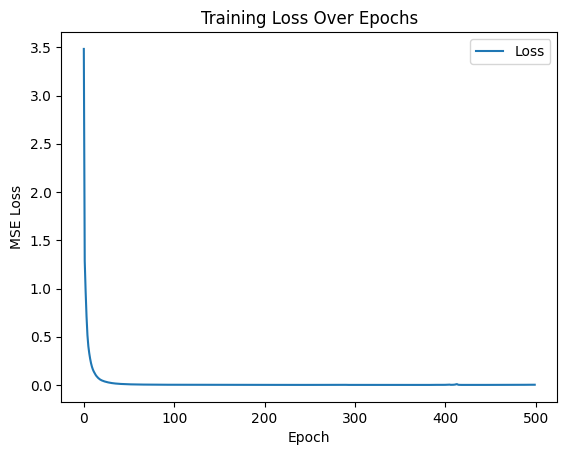

In [14]:
plt.plot(history.history['loss'], label='Loss')
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

Cell 7 — True vs Predicted Plot

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


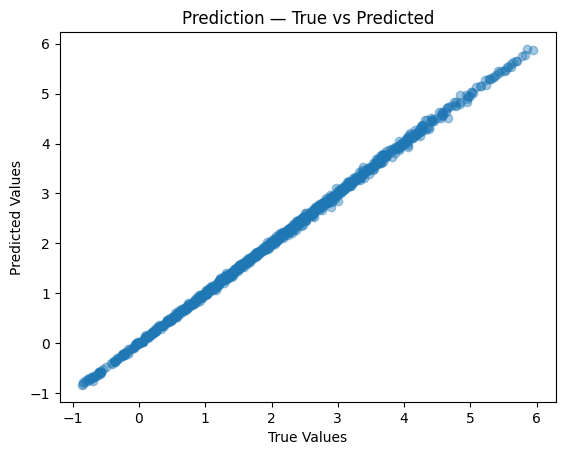

In [15]:
y_pred = model.predict(X)

plt.scatter(y, y_pred, alpha=0.4)
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Prediction — True vs Predicted")
plt.show()

Cell 8 — 4D Visualization (PCA)

We reduce the 3D input to 2 principal components to visualize results:

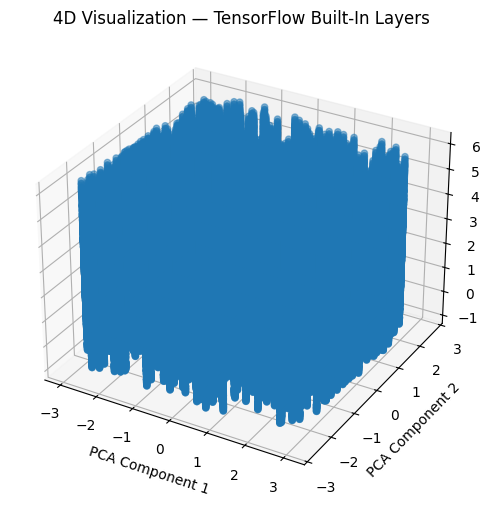

In [16]:
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_reduced[:, 0], X_reduced[:, 1], y, alpha=0.5)
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_zlabel("Output")
plt.title("4D Visualization — TensorFlow Built-In Layers")
plt.show()